# Variant-level UI Analysis with FDR Control

## Scope & Goal
This notebook identifies **individual non-default UI variants** that are associated
with higher high-intent conversion rates compared to the **global default UI**.

Key characteristics of this analysis:
- Based on **production web access logs** (observational data)
- Session-level unit of analysis
- Clean variant attribution (single-variant sessions only)
- Multiple testing control using **False Discovery Rate (FDR)**

The goal is **variant discovery and prioritization**, not causal attribution.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import sqrt
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


## 1. Session-level Dataset

We reuse the session-level table constructed previously to ensure consistency
in metric definitions and unit of analysis.


In [20]:
PATH = "../data/visit.csv"  # <- notebook在notebooks/里，所以用 ../data

df = pd.read_csv(
    PATH,
    nrows=200_000,         # EDA 先 20万行（你也可以 100k）
    sep=None,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip",
)

In [21]:
session = pd.read_parquet("../data/session_level.parquet")
# Assumes `session` already exists with:
# - session_token
# - ui_group
# - converted_hi
# - n_events
# - session_duration_sec

session.head()


,user_id,ui_group,session_start,session_end,n_events,n_unique_actions,session_duration_sec,converted_hi,is_non_default,is_bounce
session_token,,,,,,,,,,
1325679,None,default,2023-04-01 00:04:12,2023-04-01 00:04:12,1,0,0.0,0,0,1
1325691,None,default,2023-04-01 00:25:33,2023-04-01 00:25:33,1,0,0.0,0,0,1
1325701,None,default,2023-04-01 00:49:42,2023-04-01 00:49:42,1,0,0.0,0,0,1
1325705,None,default,2023-04-01 00:54:29,2023-04-01 00:54:29,1,0,0.0,0,0,1
1325706,None,default,2023-04-01 01:02:29,2023-04-01 01:02:29,1,0,0.0,0,0,1


## 2. Single-variant Session Restriction

A small fraction of sessions are exposed to more than one UI variant.
To ensure clean attribution, we restrict the analysis to sessions with
**exactly one UI variant exposure**.


In [22]:
single_variant_sessions = (
    df.groupby("session_token")["visit_group"]
      .nunique()
      .loc[lambda x: x == 1]
      .index
)

session_sv = session.loc[session.index.isin(single_variant_sessions)].copy()

session_sv.shape


(98463, 10)

## 3. Variant Eligibility Rules

We define the comparison set as follows:
- **Baseline**: global default UI (`ui_group == "default"`)
- **Candidates**: non-default UI variants
- Exclusions:
  - Variant-specific default fallbacks (`*_default`)
  - Variants with insufficient session volume

A minimum session threshold is imposed to ensure stable estimates.


In [23]:
BASELINE = "default"
MIN_SESSIONS = 300

variant_counts = session_sv["ui_group"].value_counts()

candidate_variants = (
    variant_counts
    .loc[lambda x: (x >= MIN_SESSIONS)]
    .index
    .difference([BASELINE])
)

# exclude variant-specific defaults
candidate_variants = [
    v for v in candidate_variants if not str(v).endswith("_default")
]

len(candidate_variants), candidate_variants[:10]


(5,
 ['230401_230612_1686725101__2',
  '230401_230612_1686725101__3',
  '230401_230612_1686725101__4',
  '230401_230612_1686725101__lottery',
  '8783cca2582243602a52eee552472f0856f35ff55c49ca4d97cc61f5d379b740'])

## 4. Variant-level Effect Estimation

For each candidate variant, we estimate the difference in high-intent conversion
rate relative to the global default UI.

Reported statistics:
- Conversion rates (baseline vs variant)
- Absolute lift (pp)
- 95% confidence interval (unpooled)
- z-test p-value (descriptive)


In [24]:
def variant_effect(session_df, variant, baseline=BASELINE):
    df_v = session_df[session_df["ui_group"].isin([baseline, variant])].copy()
    df_v["is_variant"] = (df_v["ui_group"] == variant).astype(int)

    g = (
        df_v.groupby("is_variant")["converted_hi"]
            .agg(["sum", "count"])
            .sort_index()
    )
    if g.shape[0] < 2:
        return None

    x0, n0 = int(g.iloc[0]["sum"]), int(g.iloc[0]["count"])
    x1, n1 = int(g.iloc[1]["sum"]), int(g.iloc[1]["count"])

    p0, p1 = x0 / n0, x1 / n1
    diff = p1 - p0

    se_ci = sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)
    zcrit = norm.ppf(0.975)
    ci_low, ci_high = diff - zcrit*se_ci, diff + zcrit*se_ci

    p_pool = (x1 + x0) / (n1 + n0)
    se_pool = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n0))
    z = diff / se_pool if se_pool > 0 else np.nan
    pval = 2 * (1 - norm.cdf(abs(z))) if np.isfinite(z) else np.nan

    return {
        "variant": variant,
        "n_baseline": n0,
        "n_variant": n1,
        "rate_baseline": p0,
        "rate_variant": p1,
        "abs_lift_pp": diff * 100,
        "ci95_low_pp": ci_low * 100,
        "ci95_high_pp": ci_high * 100,
        "p_value": pval,
    }


## 5. Scan All Eligible Variants


In [25]:
rows = []
for v in candidate_variants:
    r = variant_effect(session_sv, v)
    if r is not None:
        rows.append(r)

variant_df = (
    pd.DataFrame(rows)
      .sort_values("p_value")
      .reset_index(drop=True)
)

variant_df.head()


,variant,n_baseline,n_variant,rate_baseline,rate_variant,abs_lift_pp,ci95_low_pp,ci95_high_pp,p_value
0,8783cca2582243602a52eee552472f0856f35ff55c49ca...,91508,441,0.045056,0.106576,6.151979,3.268880,9.035079,5.864211e-10
1,230401_230612_1686725101__3,91508,377,0.045056,0.090186,4.512951,1.618333,7.407568,2.582131e-05
2,230401_230612_1686725101__4,91508,427,0.045056,0.079625,3.456912,0.885711,6.028114,6.036639e-04
3,230401_230612_1686725101__2,91508,837,0.045056,0.056153,1.109676,-0.455737,2.675088,1.237908e-01
4,230401_230612_1686725101__lottery,91508,1245,0.045056,0.053815,0.875909,-0.384717,2.136535,1.393808e-01


## 6. Multiple Testing Control (FDR)

Because many variants are evaluated simultaneously, we control the false
discovery rate using the Benjamini–Hochberg procedure.


In [26]:
rej, p_adj, _, _ = multipletests(
    variant_df["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

variant_df["p_value_fdr"] = p_adj
variant_df["reject_fdr_0.05"] = rej

variant_df.head(10)


,variant,n_baseline,n_variant,rate_baseline,rate_variant,abs_lift_pp,ci95_low_pp,ci95_high_pp,p_value,p_value_fdr,reject_fdr_0.05
0,8783cca2582243602a52eee552472f0856f35ff55c49ca...,91508,441,0.045056,0.106576,6.151979,3.268880,9.035079,5.864211e-10,2.932106e-09,True
1,230401_230612_1686725101__3,91508,377,0.045056,0.090186,4.512951,1.618333,7.407568,2.582131e-05,6.455327e-05,True
2,230401_230612_1686725101__4,91508,427,0.045056,0.079625,3.456912,0.885711,6.028114,6.036639e-04,1.006107e-03,True
3,230401_230612_1686725101__2,91508,837,0.045056,0.056153,1.109676,-0.455737,2.675088,1.237908e-01,1.393808e-01,False
4,230401_230612_1686725101__lottery,91508,1245,0.045056,0.053815,0.875909,-0.384717,2.136535,1.393808e-01,1.393808e-01,False


## 7. Product Decision Ranking

We prioritize variants that:
- show positive lift vs default
- pass FDR at 5%
- have sufficient traffic volume

This table is designed for **product decision-making**, not statistical reporting.


In [27]:
ranking = (
    variant_df[
        (variant_df["reject_fdr_0.05"]) &
        (variant_df["abs_lift_pp"] > 0)
    ]
    .sort_values("abs_lift_pp", ascending=False)
    .reset_index(drop=True)
)

ranking.insert(0, "rank", ranking.index + 1)
ranking


,rank,variant,n_baseline,n_variant,rate_baseline,rate_variant,abs_lift_pp,ci95_low_pp,ci95_high_pp,p_value,p_value_fdr,reject_fdr_0.05
0,1,8783cca2582243602a52eee552472f0856f35ff55c49ca...,91508,441,0.045056,0.106576,6.151979,3.268880,9.035079,5.864211e-10,2.932106e-09,True
1,2,230401_230612_1686725101__3,91508,377,0.045056,0.090186,4.512951,1.618333,7.407568,2.582131e-05,6.455327e-05,True
2,3,230401_230612_1686725101__4,91508,427,0.045056,0.079625,3.456912,0.885711,6.028114,6.036639e-04,1.006107e-03,True


## 8. Visualization: Variant Effects Overview


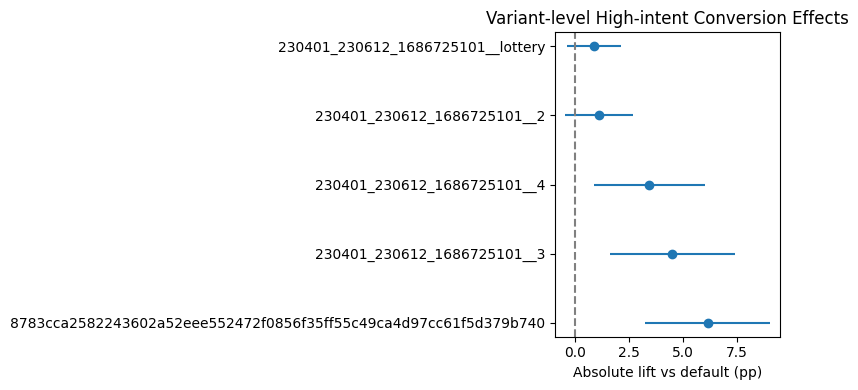

In [28]:
plt.figure(figsize=(8, max(4, len(variant_df) * 0.25)))

plt.errorbar(
    variant_df["abs_lift_pp"],
    range(len(variant_df)),
    xerr=[
        variant_df["abs_lift_pp"] - variant_df["ci95_low_pp"],
        variant_df["ci95_high_pp"] - variant_df["abs_lift_pp"],
    ],
    fmt="o"
)

plt.yticks(range(len(variant_df)), variant_df["variant"])
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Absolute lift vs default (pp)")
plt.title("Variant-level High-intent Conversion Effects")
plt.tight_layout()
plt.show()


## Final Interpretation & Product Decision

### Confirmed high-performing variants
Using a discovery threshold of `MIN_SESSIONS = 300` and controlling the false discovery
rate at 5%, we identify **three UI variants** that are robustly associated with higher
high-intent conversion rates compared to the global default UI.

These variants show:
- Large absolute lift (+3.5 to +6.2 pp)
- 95% confidence intervals fully above zero
- Statistical significance after FDR correction

### Interpretation caveats
This analysis is based on observational production logs. While the magnitude and robustness
of these effects are compelling, the results should be interpreted as **associational** rather
than strictly causal.

### Product implications
- The confirmed variants represent strong candidates for prioritized rollout or controlled
  A/B testing.
- Variants with positive but non-significant lift may warrant additional data collection
  or targeted experimentation.
- The ranking table provides a practical short-list for decision-making under uncertainty.
